## Module 3 — Pattern / Text Mining

**Initial task description (Module 3 perspective):** 
Building upon our structural refinements in modules 1 and 2, our third analysis phase shifts focus from how we formally define "listening contexts" (clustering) to how we can exploit them (recommendations). In the previous phases, our evaluation pipeline measured cluster quality using Collaborative Filtering. Although a clear-cut solution, this method is notoriously susceptible to data sparsity (Banerjee, 2024), and estimates preferences based on general alignment, which could miss the strict thematic combinations that characterize music.

To address this limitation, we pivot to Pattern Mining. By applying frequent itemset mining and association rules internally within our established clusters, we can extract co-occurrence patterns that allow use to recommend tracks based on deterministic relationships rather than generalized user similarity. While pattern mining is generally even more vulnerable to sparsity than CF, executing it within our topologically dense clusters raises local support, allowing us to capture localized rules that would be invisible at a global scale. As pattern mining prioritizes precision over broad coverage, we integrate our original Collaborative Filtering model as a dynamic fallback mechanism. Ultimately, this approach investigates a core behavioural question: within a cohesive community, is human musical curation better predicted by exact programmatic track associations, or by generalized socio-musical alignment?

### Reproducibility and Setup


In [1]:
# prelims
import pandas as pd
import os
from evaluation.evaluator import eval
from pattern_mining.rules.FPGrowGenerator import FPGrowthGenerator
from notebook_helper import compare_results 

In [2]:
# chore, load vars which we need for analysis
# load the dataframe 
from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
df = pd.read_parquet(FULLY_PROCESSED_PARQUET)
# load the tfidf matrix, unique texts and vectorizer for later use in part 2-3
from clustering.tf_idf_analysis.tf_idf_analysis import load_tfidf_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_cache_dir = "data/tfidf_cache"
tfidf_matrix, unique_texts, vectorizer = load_tfidf_matrix(tfidf_cache_dir, df, TfidfVectorizer)

[INFO] Loading cached, cleaned TF-IDF matrix and unique texts...
[INFO] Loaded TF-IDF matrix shape: (84696, 5678)


In [3]:
# We would like to evaluate SVDKMeans, on both pure CF and hybrid
svd_kmeans_cluster_col = "svd200_kmeans_55"
hybrid_output_dir = "evaluation/reports/Hybrid_FPGrowth_CF"

### Algorithmic Selection 
We have chosen FP-Growth specifically to execute this mining process due to its superior efficiency compared to the standard Apriori method. 
- Utilizing an FP-tree it stores a compressed representation of the transaction database, reducing memory overhead during the mining process. 
- By mining suffixes bottom-up through conditional FP-trees, the algorithm ensures that once the thresholds are defined, the rules are extrated with optimal time complexity relative to the data.


### Hyperparameter Selection
The effectiveness of the association rule mining implementation relies on the calibration of two primary hyperparameters, minimum support and minimum confidence. These parameters acts as a statistical filter to ensure that only the most robust and predictive patterns are promoted to the hybrid recommendation set. 
 

#### Minimum Support (0.015)
Support defines the global frequency of an itemset (a combination of tracks) within a specific cluster dataset. we established a threshold of 1.5% for the following reasons.
- This particular threshold allows the FP-Growth algorithm to prune (limit) the search space of $2^d$ potential combinations efficiently, preventing the "combinatorial explosion" that occurs when dealing with high-dimensionality playlist data. Effectively decreasing the computing time. 
- Setting the *minsup* at 0.015 ensures that the engine ignores stochastic noise (track pairings that appear together purely by chance) and instead focuses on patterns that represent a consistent sub-trend within the cluster's musical community. 


#### Minimum Confidence (0.30)
Confidence measures the conditional probability of a rule, determining the likelihood that a user will listen to track *Y* given that their playlist already contains track *X*. We selected a 30% threshold based on several factors.
- We wanted a threshold which ensures that every rule generated has a statistically significant "hit rate" without being so restrictive that it only captures obvious associations. 
- We are trying to avoid the "Album Effect" which comes from setting confidence too high, ending up in capturing redundant associations, such as different tracks from the same album. 

### Rule Creation and Analysis (FP-Growth)


CALCULATING SILHOUETTE SCORE

CALCULATING SILHOUETTE SCORE FOR svd200_kmeans_55
-> Final Silhouette Score (svd200_kmeans_55): 0.1148

Processing Cluster 32.0...
Number of samples in Cluster 32.0: 2849225
  -> Successfully split 11016 users into train/test sets.
[FP-Growth | Cluster 32.0] Checking master Parquet...
[FP-Growth | Cluster 32.0] Mining new rules...
[FP-Growth] Generated 0 rules based on support and confidence.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 32.0 ---
Items from Rules: 0 (0.0%)
Items from CF:    66731886 (100.0%)
Coverage: 0/200 users received rule-based tips.

Processing Cluster 12.0...
Number of samples in Cluster 12.0: 598278
  -> Successfully split 6266 users into train/test sets.
[FP-Growth | Cluster 12.0] Checking master Parquet...
[FP-Growth | Cluster 12.0] Mining new rules...
[FP-Growth] Generated 0 rules based on support and confidence.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 12.0 ---
Items from Rules: 0 (0.0%)
Items from CF:    8440668 (100.0%)
Coverage: 0/200 users received rule-based tips.

Processing Cluster 2.0...
Number of samples in Cluster 2.0: 181794
  -> Successfully split 3129 users into train/test sets.
[FP-Growth | Cluster 2.0] Checking master Parquet...
[FP-Growth] Loaded 100 rules from Parquet in 0.04s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 2.0 ---
Items from Rules: 104 (0.0%)
Items from CF:    1945643 (100.0%)
Coverage: 22/200 users received rule-based tips.

Processing Cluster 4.0...
Number of samples in Cluster 4.0: 178788
  -> Successfully split 685 users into train/test sets.
[FP-Growth | Cluster 4.0] Checking master Parquet...
[FP-Growth] Loaded 941 rules from Parquet in 0.05s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 4.0 ---
Items from Rules: 414 (0.0%)
Items from CF:    5909584 (100.0%)
Coverage: 56/200 users received rule-based tips.

Processing Cluster 6.0...
Number of samples in Cluster 6.0: 166844
  -> Successfully split 1557 users into train/test sets.
[FP-Growth | Cluster 6.0] Checking master Parquet...
[FP-Growth] Loaded 1719 rules from Parquet in 0.05s.
  -> Generating recommendations & evaluating 200 sampled users...


...


--- Trace for Cluster 38.0 ---
Items from Rules: 78 (0.2%)
Items from CF:    43412 (99.8%)
Coverage: 16/200 users received rule-based tips.

Processing Cluster 50.0...
Number of samples in Cluster 50.0: 17307
  -> Successfully split 329 users into train/test sets.
[FP-Growth | Cluster 50.0] Checking master Parquet...
[FP-Growth] Loaded 1618 rules from Parquet in 0.04s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 50.0 ---
Items from Rules: 1445 (0.3%)
Items from CF:    466679 (99.7%)
Coverage: 93/200 users received rule-based tips.

Processing Cluster 51.0...
Number of samples in Cluster 51.0: 16048
  -> Successfully split 639 users into train/test sets.
[FP-Growth | Cluster 51.0] Checking master Parquet...
[FP-Growth] Loaded 5509 rules from Parquet in 0.05s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 51.0 ---
Items from Rules: 569 (1.7%)
Items from CF:    32435 (98.3%)
Coverage: 69/200 users received rule-based tips.

Processing Cluster 48.0...
Number of samples in Cluster 48.0: 12156
  -> Successfully split 598 users into train/test sets.
[FP-Growth | Cluster 48.0] Checking master Parquet...
[FP-Growth] Loaded 2418 rules from Parquet in 0.05s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 48.0 ---
Items from Rules: 342 (2.3%)
Items from CF:    14782 (97.7%)
Coverage: 57/200 users received rule-based tips.

Processing Cluster 35.0...
Number of samples in Cluster 35.0: 11732
  -> Successfully split 381 users into train/test sets.
[FP-Growth | Cluster 35.0] Checking master Parquet...
[FP-Growth] Loaded 74578 rules from Parquet in 0.09s.
  -> Generating recommendations & evaluating 200 sampled users...



--- Trace for Cluster 35.0 ---
Items from Rules: 2285 (7.9%)
Items from CF:    26814 (92.1%)
Coverage: 64/200 users received rule-based tips.

Saving metrics to evaluation/reports/Hybrid_FPGrowth_CF/evaluation_metrics_svd200_kmeans_55.txt...
Rule activation stats saved to evaluation/reports/Hybrid_FPGrowth_CF/rule_activation_stats.json

Generating evaluation graphs...
Graph successfully saved as 'evaluation/reports/Hybrid_FPGrowth_CF/f01_comparison.png'


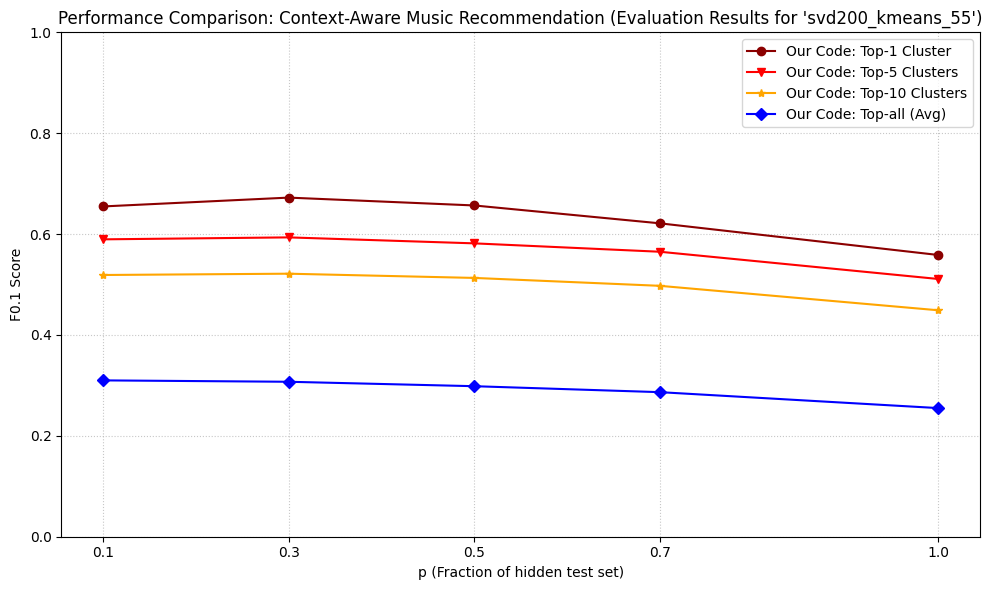


PLOTTING CLUSTER DISTRIBUTION
-> Distribution graph saved successfully to: evaluation/reports/Hybrid_FPGrowth_CF/cluster_distribution.png


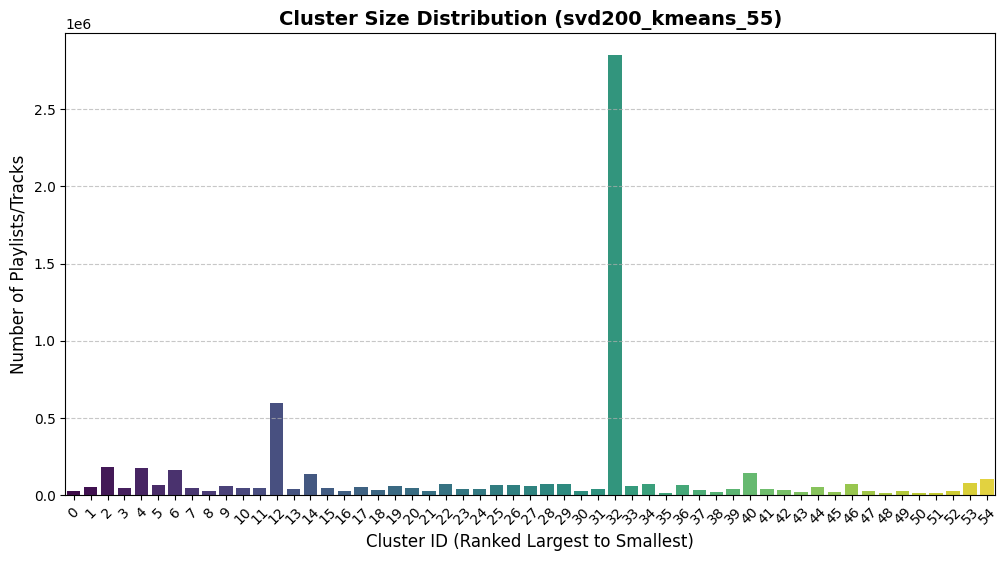


=== FINAL EVALUATION AVERAGES ===
Top-1 Average:   [np.float64(0.6548), np.float64(0.6723), np.float64(0.6568), np.float64(0.6214), np.float64(0.5586)]
Top-5 Average:   [np.float64(0.5896), np.float64(0.5935), np.float64(0.5816), np.float64(0.565), np.float64(0.511)]
Top-all Average: [np.float64(0.31), np.float64(0.3072), np.float64(0.2984), np.float64(0.2866), np.float64(0.255)]


In [4]:
# Defining the rule generator with desired parameters
fp_generator = FPGrowthGenerator(
    min_support_pct=0.015, # rule must appear in at least x% of transactions (playlists) to be considered
    min_confidence=0.30, 
    config_name="hybrid_test_01"
)

# Running the evaluation for the hybrid approach, which will also trigger rule mining and evaluation within the eval function

# if results already made, then skip
if os.path.exists(hybrid_output_dir):
    print(f"Results already exist in {hybrid_output_dir}, skipping evaluation.")
else:
    eval(
        df=df, 
        cluster_col=svd_kmeans_cluster_col, 
        unique_texts=unique_texts, 
        tfidf_matrix=tfidf_matrix, 
        output_dir=hybrid_output_dir,
        rule_generator=fp_generator, # trigger rule mining and evaluation within the eval function
    )

In [5]:
# Now we can analyze the generated rules and their relationship to the evaluation metrics
from evaluation.rule_analysis_helper import AssociationRuleAnalyzer
analyzer = AssociationRuleAnalyzer()

Index(['antecedents', 'consequents', 'antecedent support',
       'consequent support', 'support', 'confidence', 'lift',
       'representativity', 'leverage', 'conviction', 'zhangs_metric',
       'jaccard', 'certainty', 'kulczynski', 'cluster_id'],
      dtype='str')


#### Popularity Bias

In music datasets, global hits (e.g., a Taylor Swift or The Weeknd track) act as statistical magnets. Because their "Support($B$)" is naturally high, the "Confidence($A \rightarrow B$)" will almost always be high, regardless of what item $A$ is. Lift corrects this by dividing the Confidence by the probability of $B$ occurring anyway. It is calculated as the ratio of the observed support to the expected support if the two items were completely independent. 
$$\text{(eq 1)}: \text{Lift}(A \rightarrow B) = \frac{\text{Confidence}(A \rightarrow B)}{\text{Support($B$})}.$$
The value of Lift is generally interpreted against a baseline of 1:
- Lift > 1 means that there is a positive correlation. 
- Lift = 1 implies no relationship between A and B.
- Lift < 1 indicate a negative or inverse association. In this case, the presence of the A decreases the likelihood of B.

The average lift across all cluster is printed below.

In [6]:
analyzer.print_average_lift()

Average Lift across all clusters: 17.8704


The average lift of 18.0 across all clusters confirms that our model has successfully moved beyond global popularity to find highly specific associations. However, a lift of this magnitude also warrants a critical look at potential pitfalls.

Mathematically, while a Lift of 18 indicates a relationship 18 times stronger than random chance, it often signals over-specialization. In music data, such high values frequently arise from 'identity rules', where the algorithm recommends tracks from the same album or artist or from false correlations caused by extremely low support for niche items. While this effectively solves the Popularity Trap, it risks creating a 'Filter Bubble' or an 'Echo Chamber', where recommendations become so predictable or hyper-niche that they lack the adversity for music discovery. Consequently, while these high lift values prove the algorithm's ability to find deep latent connections, they must be balanced with diversity constraints to ensure the system remains useful for discovery rather than just confirming existing listening patterns.

In [7]:
analyzer.plot_metric_distributions()

AttributeError: 'AssociationRuleAnalyzer' object has no attribute 'plot_metric_distributions'

The most notable thing here is that there's a large concentration of rules which have a lift barely breaking $1.0$ showing slight correlation, but indicating weakness. We also have some frequently occuring extremas receiving a confidence score of exactly 1.0, we found this to often occur in well partitioned clusters like 7.0 (which represents christmas songs), where a rule such as
$$\{\text{Little Drummer Boy}\} \Rightarrow \{\text{The First Noel}\}, \text{confidence} = 1.0$$
implies that whenever Little Drummer Boy occurs, then The First Noel co-occurs. 

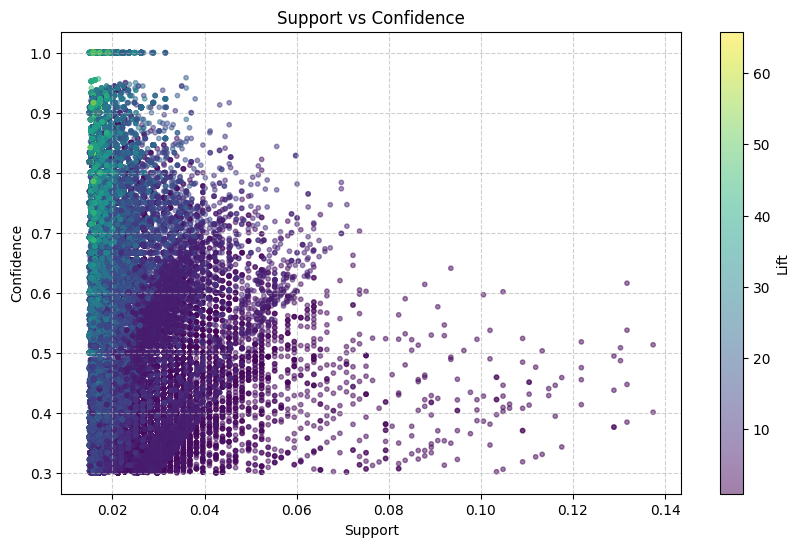

In [ ]:
analyzer.plot_support_vs_confidence()

The distribution in the Support vs. Confidence plot confirms the inverse relationship between Support and Lift as defined by (eq 1). High-Lift rules (bright yellow/green) are exclusively concentrated in the low-support region ($< 0.03$), representing niche, high-affinity associations that characterize personalized discovery. Conversely, as Support increases, representing the 'Popularity Trap' of global hits, the Lift consistently drops toward the baseline of 1.0 (indicated by the purple cluster extending to the right). This visualization justifies our use of Lift: by filtering for high-lift values, we effectively prune away the high-support/low-lift rules that offer reliability (Confidence) but lack the specific correlation required for a high-quality recommendation.

### Evaluation

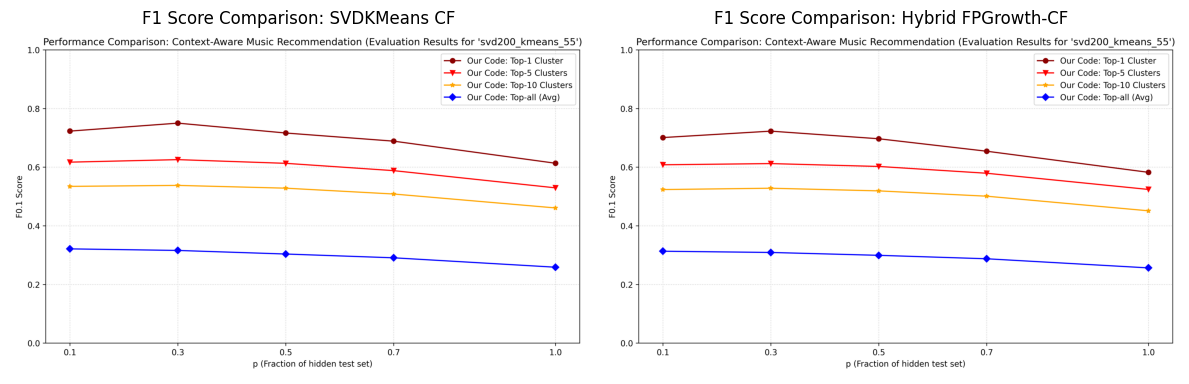

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Plotting the results
cf_f_score_plot = "clustering/reports/SVDKMeans/svd200_k55_ninit10_maxiter300/f01_comparison.png"
rules_cf_f_score_plot = "evaluation/reports/Hybrid_FPGrowth_CF/f01_comparison.png"
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(mpimg.imread(cf_f_score_plot))
ax[0].set_title("F1 Score Comparison: SVDKMeans CF")
ax[0].axis('off')

ax[1].imshow(mpimg.imread(rules_cf_f_score_plot))
ax[1].set_title("F1 Score Comparison: Hybrid FPGrowth-CF")
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### Evaluating Activated Rules

In [ ]:
# Better more detailed viewing
hybrid_txt = "evaluation/reports/Hybrid_FPGrowth_CF/evaluation_metrics_svd200_kmeans_55.txt"
pure_cf_txt = "clustering/reports/SVDKMeans/svd200_k55_ninit10_maxiter300/evaluation_metrics_svd200_kmeans_55.txt"

if os.path.exists(pure_cf_txt) and os.path.exists(hybrid_txt):
    flat_df, table = compare_results(pure_cf_txt, hybrid_txt)
    display(table)
else:
    print("Check your file paths; one or both reports are missing.")

#### Overall Trends
A comparative analysis of the F0.1 scores across a varying ($p$) reveals a marginal, yet systematic, performance reduction in the hybrid model compared to the pure collaborative filtering (CF) baseline. As evidenced in the **Delta** values, the integration of FP-Growth association rules resulted in a consistent decline in precision across the cluster tiers. Rather than boosting the performance of the baseline, injecting these deterministic patterns actually handicapped the recommender's ability to retrieve relevant tracks.

#### Dilution Investigation
Given the extremely marginal difference in performance compared to the baseline, we initially hypothesized that the generated FP-Growth rules were rarely being triggered, causing the system to predominantly default to the collaborative filtering mechanism. Further investigation of the rule application rate confirmed this limitation (See...). 

This presents a significant structural paradox for hyperparameter tuning. If we decrease the minimum support and confidence thresholds to ensure the rules trigger more frequently, we risk injecting weak associations that actively degrade the recommendation quality, as we see the beginning of now. Conversely, if we increase the thresholds to ensure only the highest-quality rules are utilized, the rules trigger so infrequently that the hybrid model becomes functionally identical to the pure collaborative filtering baseline.

Ultimately, this indicates that pattern mining is inherently constrained by the quality of the underlying partitions. For a hybrid rule-based system to significantly outperform generalized collaborative filtering, the base clusters must exhibit exceptionally high intra-cluster song cohesion, such as the strict thematic density observed in Cluster 7. Without such rigid semantic boundaries, absolute association rules fail to generalize effectively across sparse user playlists compared to probabilistic alignment. We hypothesize that the method would perform significantly better if the clusters were based on direct track co-occurrences, rather than the semantic text of playlist titles. By clustering based on the actual tracks contained within the playlists, we would inherently guarantee the baseline item density required for frequent itemset mining to thrive.

#### Refining Results (Filtering rules)

Given our findings regarding dilution and the negative impact of weak associations, the only viable path forward is to strategically filter the rules at inference time. While we cannot logically expect this to drastically outperform the pure Collaborative Filtering baseline, our hope is that strictly curating these rules will yield extremely marginal improvements, or at the very least, stem the performance deficit we observed in the initial hybrid execution.

By passing `refine_results=True` to our evaluation pipeline, we fundamentally alter how the association rules are injected into the recommendation pool:

1. **Strict Lift-Based Filtering**: Instead of blindly accepting all rules that satisfy our baseline support and confidence thresholds, we mandate a strict minimum $\text{lift} > 2.0$. This isolates tracks that share a strong positive correlation and actively weeds out barely-correlated popular tracks (which have a natural lift near 1.0) that were suffocating the CF engine.
2. **Dynamic Quota Allocation**: To prevent the "Album Effect" and high-confidence sequences from completely overwriting the CF model's diversity, we cap the maximum number of rule-based track injections to a dynamic limit (accounting for a maximum of 20% of the total recommended output pool). 
3. **Lift Prioritization**: We sort the surviving rules by their Lift score in descending order, ensuring that only the most robust, deterministic associations are promoted to the top of the recommendation queue before gracefully falling back to generalized CF predictions.


In [ ]:
# el muchacho betterino
refined_output_dir = hybrid_output_dir + "/refine_results"
if os.path.exists(refined_output_dir):
    print(f"Refined results already exist in {refined_output_dir}, skipping re-evaluation.")
else:
     eval(df=df,
          cluster_col=svd_kmeans_cluster_col, 
          unique_texts=unique_texts, 
          tfidf_matrix=tfidf_matrix, 
          output_dir=refined_output_dir,
          rule_generator=fp_generator,
          refine_results=True, 
     )

Refined results already exist in evaluation/reports/Hybrid_FPGrowth_CF/refine_results, skipping re-evaluation.


In [ ]:
# Better more detailed viewing
hybrid_txt = "evaluation/reports/Hybrid_FPGrowth_CF/refine_results/evaluation_metrics_svd200_kmeans_55.txt"
pure_cf_txt = "clustering/reports/SVDKMeans/svd200_k55_ninit10_maxiter300/evaluation_metrics_svd200_kmeans_55.txt"

if os.path.exists(pure_cf_txt) and os.path.exists(hybrid_txt):
    flat_df, table = compare_results(pure_cf_txt, hybrid_txt)
    display(table)
else:
    print("Check your file paths; one or both reports are missing.")